# 02 — Fiabilidad y clases
*¿En qué podemos confiar?*

El modelo YOLOv5n se usa **sin fine-tuning** en el dominio de conducción y **sin ground-truth exhaustivo**. Este notebook convierte esa limitación en método: (A2) triaje de relevancia de clase, sensibilidad al umbral, y (A1) una validación manual *parcial* que produce precisión por clase con intervalos de confianza honestos (Wilson) y un umbral operativo justificado por clase.

> **Alcance del análisis de peligro:** Horn(0) + Siren(1). Speech(4) se trata como *contexto*, nunca como peligro. El resto son clases del dataset YOLO original (fuera de dominio).

In [2]:
import sys, warnings
sys.path.insert(0, "../scripts")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geo_utils as gu

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.width", 140)

geo = gu.load_geo()
geo = geo[~geo["trayecto"].isin(gu.BAD_TRAYECTOS)].copy()
geo["class_name"] = geo["class"].map(gu.CLASS_NAMES)
print(f"{len(geo):,} detecciones geolocalizadas | fuentes: {geo['source'].unique().tolist()}")
geo.head(3)

14,985 detecciones geolocalizadas | fuentes: ['mic', 'mobile']


,microfono_id,t_start,t_end,class,confidence,source_file,session_id,source,date,duration_s,lat,lon,trayecto,class_name
0,1,2026-03-11 19:22:32.494373+00:00,2026-03-11 19:22:37.045898+00:00,0,0.130318,20260311_21_22_27_0739_M1.wav,20260311,mic,11-03-2026,4.551525,39.514295,-0.423465,ETSE-PAIPORTA_1,Horn
1,1,2026-03-11 19:22:36.084597+00:00,2026-03-11 19:22:36.836745+00:00,3,0.188487,20260311_21_22_27_0739_M1.wav,20260311,mic,11-03-2026,0.752148,39.514295,-0.423465,ETSE-PAIPORTA_1,Physiological
2,1,2026-03-11 19:22:36.926335+00:00,2026-03-11 19:22:37.738812+00:00,3,0.100677,20260311_21_22_32_0075_M1.wav,20260311,mic,11-03-2026,0.812477,39.514295,-0.423465,ETSE-PAIPORTA_1,Physiological


## A2 — Triaje de relevancia de clase / desajuste de dominio
Cuántas detecciones aporta cada clase y qué fracción cae **fuera de dominio** (imposible/ruido en un coche). Argumento para restringir el peligro a Horn+Siren.

In [3]:
counts = (geo.groupby("class")
          .size().rename("n").reset_index())
counts["name"] = counts["class"].map(gu.CLASS_NAMES)
def relevancia(c):
    if c in gu.ROAD_CLASSES:    return "Vial (peligro)"
    if c in gu.CONTEXT_CLASSES: return "Contexto"
    return "Fuera de dominio"
counts["grupo"] = counts["class"].apply(relevancia)
counts["pct"] = (100 * counts["n"] / counts["n"].sum()).round(1)
display(counts.sort_values("n", ascending=False))
print("Fuera de dominio:", counts.loc[counts.grupo=="Fuera de dominio","pct"].sum().round(1), "% de las detecciones")

,class,n,name,grupo,pct
4,4,4965,Speech,Contexto,33.1
5,5,3390,Ring Tone,Fuera de dominio,22.6
6,6,3081,Vibrating,Fuera de dominio,20.6
3,3,1952,Physiological,Fuera de dominio,13.0
2,2,958,Pets,Fuera de dominio,6.4
0,0,476,Horn,Vial (peligro),3.2
8,8,93,Cry,Fuera de dominio,0.6
1,1,38,Siren,Vial (peligro),0.3
7,7,32,Notifications,Fuera de dominio,0.2


Fuera de dominio: 63.4 % de las detecciones


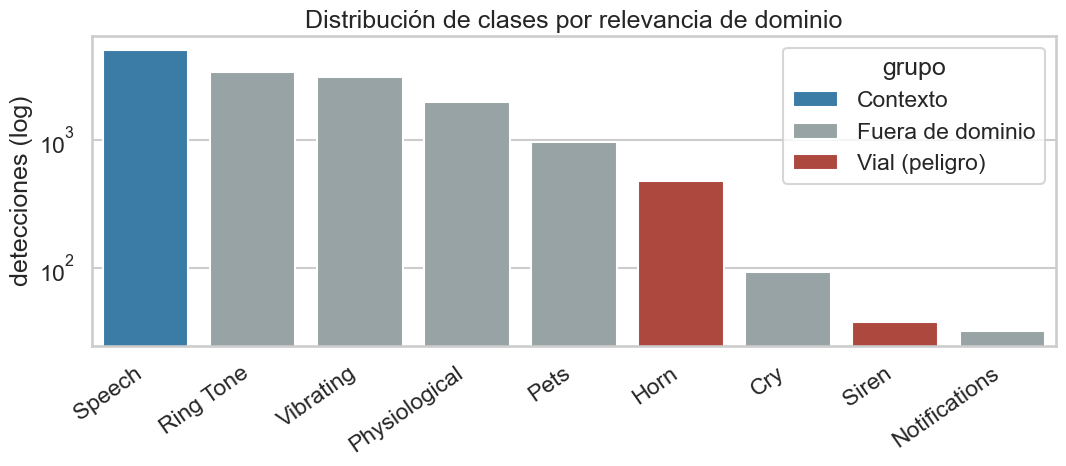

In [4]:
order = counts.sort_values("n", ascending=False)
palette = {"Vial (peligro)": "#c0392b", "Contexto": "#2980b9", "Fuera de dominio": "#95a5a6"}
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=order, x="name", y="n", hue="grupo", palette=palette, dodge=False, ax=ax)
ax.set_yscale("log"); ax.set_xlabel(""); ax.set_ylabel("detecciones (log)")
ax.set_title("Distribución de clases por relevancia de dominio")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/nbA_class_domain.png", dpi=130, bbox_inches="tight"); plt.show()

**Lectura.** Speech domina (radio/conversación). Horn y Siren —las únicas señales de peligro vial— son minoritarias (Siren especialmente escasa). Una fracción grande de detecciones pertenece a clases fuera de dominio: deben considerarse falsos positivos y excluirse del danger score.

## Sensibilidad al umbral de confianza
El umbral 0.10→0.80 mueve drásticamente el recuento. ¿Cuántos eventos sobreviven por clase y fuente a cada umbral?

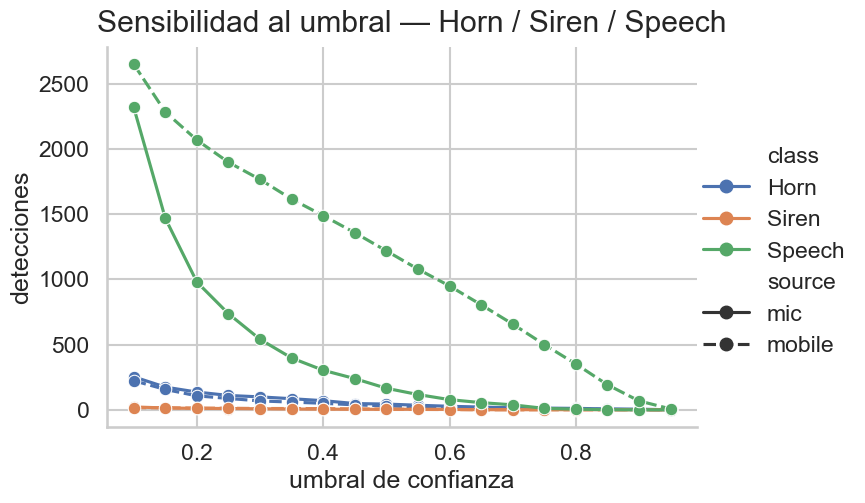

In [5]:
ths = np.round(np.arange(0.1, 0.96, 0.05), 2)
focus = [0, 1, 4]
rows = []
for th in ths:
    sub = geo[geo.confidence >= th]
    for c in focus:
        for src in ["mic", "mobile"]:
            rows.append({"th": th, "class": gu.CLASS_NAMES[c], "source": src,
                         "n": int(((sub["class"]==c) & (sub.source==src)).sum())})
sens = pd.DataFrame(rows)
g = sns.relplot(data=sens, x="th", y="n", hue="class", style="source",
                kind="line", marker="o", height=5, aspect=1.5)
g.set(xlabel="umbral de confianza", ylabel="detecciones")
g.fig.suptitle("Sensibilidad al umbral — Horn / Siren / Speech", y=1.02)
g.savefig("../outputs/nbA_threshold_sensitivity.png", dpi=130, bbox_inches="tight")

## A1 — Validación manual parcial + calibración
Sin ground-truth completo. Tomamos una **muestra estratificada** (clase × bin de confianza), la escuchamos y etiquetamos TP/FP. Con ~50–80 etiquetas estimamos precisión por clase con **IC de Wilson** (intervalos anchos, declarados).

**Paso 1 — exportar hoja de muestreo** (`validation/sampling_sheet.csv`). Rellenar columna `is_tp` ∈ {0,1} escuchando cada clip (`source_file` + `t_start`/`t_end`).

In [6]:
from pathlib import Path
Path("../validation").mkdir(exist_ok=True)
N_PER_CELL = 8          # detecciones por celda clase×bin
TARGET_CLASSES = [0, 1, 4, 5, 6]   # viales + contexto + 2 fuera-dominio de control
bins = pd.IntervalIndex.from_breaks([0.1, 0.3, 0.5, 0.7, 0.85, 1.0])
samp = geo[geo["class"].isin(TARGET_CLASSES)].copy()
samp["conf_bin"] = pd.cut(samp.confidence, bins)
cols = ["trayecto", "source", "source_file", "t_start", "t_end", "class", "class_name", "confidence"]
parts = []
for _, d in samp.groupby(["class", "conf_bin"], observed=True):
    parts.append(d.sample(min(len(d), N_PER_CELL), random_state=42))
sheet = pd.concat(parts)[cols].copy()
sheet["is_tp"] = ""        # <-- rellenar a mano: 1=correcto, 0=falso positivo
out = "../validation/sampling_sheet.csv"
sheet.to_csv(out, index=False)
print(f"{len(sheet)} clips -> {out}. Escuchar y rellenar 'is_tp'.")
sheet.head()

185 clips -> ../validation/sampling_sheet.csv. Escuchar y rellenar 'is_tp'.


,trayecto,source,source_file,t_start,t_end,class,class_name,confidence,is_tp
14668,BURJASOT-SILLA,mobile,gated_20260527_19_01_18_0000_M0.wav,2026-05-27 19:05:33.853049+00:00,2026-05-27 19:05:34.298569+00:00,0,Horn,0.134377,
140,ETSE-PAIPORTA_1,mic,20260311_21_28_31_0477_M1.wav,2026-03-11 19:28:32.109111+00:00,2026-03-11 19:28:32.307543+00:00,0,Horn,0.161947,
2593,PAIPORTA-ETSE_4,mic,20260401_14_51_37_0663_M2.wav,2026-04-01 12:51:43.381614+00:00,2026-04-01 12:51:47.015862+00:00,0,Horn,0.206890,
2873,PAIPORTA-ETSE_4,mic,20260401_15_01_08_0109_M1.wav,2026-04-01 13:01:08.049065+00:00,2026-04-01 13:01:08.915784+00:00,0,Horn,0.162107,
990,ETSE-PAIPORTA_2,mic,20260323_20_38_45_0372_M2.wav,2026-03-23 18:38:46.599093+00:00,2026-03-23 18:38:46.827854+00:00,0,Horn,0.222567,


**Paso 2 — calcular precisión** (se ejecuta cuando la hoja esté rellenada). Si aún no hay etiquetas, esta celda lo avisa y se salta sin romper el notebook.

In [7]:
lab_path = Path("../validation/labels.csv")
src_path = Path("../validation/sampling_sheet.csv")
use = lab_path if lab_path.exists() else src_path
labels = pd.read_csv(use)
labels = labels[pd.to_numeric(labels["is_tp"], errors="coerce").notna()].copy()
labels["is_tp"] = labels["is_tp"].astype(int)
if labels.empty:
    print("Sin etiquetas todavía. Rellenar is_tp en", src_path, "y re-ejecutar.")
    prec = None
else:
    prec = gu.class_precision(labels)
    display(prec)

Sin etiquetas todavía. Rellenar is_tp en ..\validation\sampling_sheet.csv y re-ejecutar.


In [8]:
if prec is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(prec))
    ax.errorbar(prec.precision, y,
                xerr=[prec.precision - prec.ci_lo, prec.ci_hi - prec.precision],
                fmt="o", capsize=5, color="#c0392b")
    ax.set_yticks(y); ax.set_yticklabels(prec["name"]); ax.set_xlim(0, 1)
    ax.set_xlabel("precisión (IC Wilson 95%)")
    ax.set_title(f"Precisión por clase — validación parcial (n={int(prec.n.sum())})")
    plt.tight_layout(); plt.savefig("../outputs/nbA_precision_ci.png", dpi=130); plt.show()
else:
    print("(figura de precisión pendiente de etiquetas)")

(figura de precisión pendiente de etiquetas)


## Calibración: confianza → precisión empírica
¿La confianza del modelo predice la corrección? Agrupamos las etiquetas por bin de confianza y comparamos con la diagonal ideal. Define el **umbral operativo por clase**.

In [9]:
if prec is not None and len(labels) >= 10:
    labels["conf_bin"] = pd.cut(labels.confidence, bins)
    cal = (labels.groupby("conf_bin", observed=True)
                 .agg(emp_prec=("is_tp", "mean"), n=("is_tp", "size"),
                      conf_mid=("confidence", "mean")).reset_index())
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "--", color="gray", label="ideal")
    ax.scatter(cal.conf_mid, cal.emp_prec, s=cal.n*20, color="#2980b9", zorder=3)
    for _, r in cal.iterrows():
        ax.annotate(f"n={int(r.n)}", (r.conf_mid, r.emp_prec), fontsize=10)
    ax.set_xlabel("confianza media (bin)"); ax.set_ylabel("precisión empírica")
    ax.set_title("Curva de calibración"); ax.legend()
    plt.tight_layout(); plt.savefig("../outputs/nbA_calibration.png", dpi=130); plt.show()
    display(cal)
else:
    print("Calibración pendiente de >=10 etiquetas.")

Calibración pendiente de >=10 etiquetas.


### Salida del notebook
- Tabla de precisión por clase con IC → `outputs/nbA_precision_ci.png`.
- Umbral operativo por clase (elegir el bin donde la precisión empírica supera el objetivo, p.ej. 0.7). Estos pesos de precisión alimentan el **danger score v2** (NB-04).
- **Limitación declarada:** validación parcial → IC anchos; no se sobrevende precisión.

## A3 — Fiabilidad entre las 6 pasadas PAIPORTA-ETSE

Las 6 repeticiones de la misma ruta (mismo sensor, condiciones similares) permiten cuantificar el **suelo de ruido del detector**: cuánto varía el recuento por clase cuando no cambia nada estructural.

- **CV (coeficiente de variación)** = std / media por clase a través de las 6 pasadas. CV < 0.25 = clase fiable; CV > 0.50 = clase inestable.
- **Consistencia espacial**: celdas ~100 m. ¿El detector activa las mismas zonas geográficas en todas las pasadas?
  - **Índice Jaccard** entre pares de pasadas (detecciones de cualquier clase).
  - **% celdas presentes en ≥ 4/6 pasadas** = fracción de zonas estables.
- **Mapa de consistencia**: verde = zona activa en ≥ 5 pasadas; rojo = solo 1.

Pasadas encontradas: ['PAIPORTA-ETSE_2', 'PAIPORTA-ETSE_3', 'PAIPORTA-ETSE_4', 'PAIPORTA-ETSE_5', 'PAIPORTA-ETSE_6']
Total eventos: 3414

CV por clase (6 pasadas PAIPORTA-ETSE):


,media,std,CV,fiabilidad
class_name,,,,
Pets,44.4,11.5,0.258,media
Speech,185.6,67.8,0.365,media
Physiological,106.2,57.1,0.538,baja
Ring Tone,135.0,76.9,0.570,baja
Horn,19.8,12.7,0.642,baja
Vibrating,189.6,153.1,0.808,baja
Notifications,1.4,1.3,0.958,baja
Siren,0.6,1.3,2.236,baja
Cry,0.2,0.4,2.236,baja


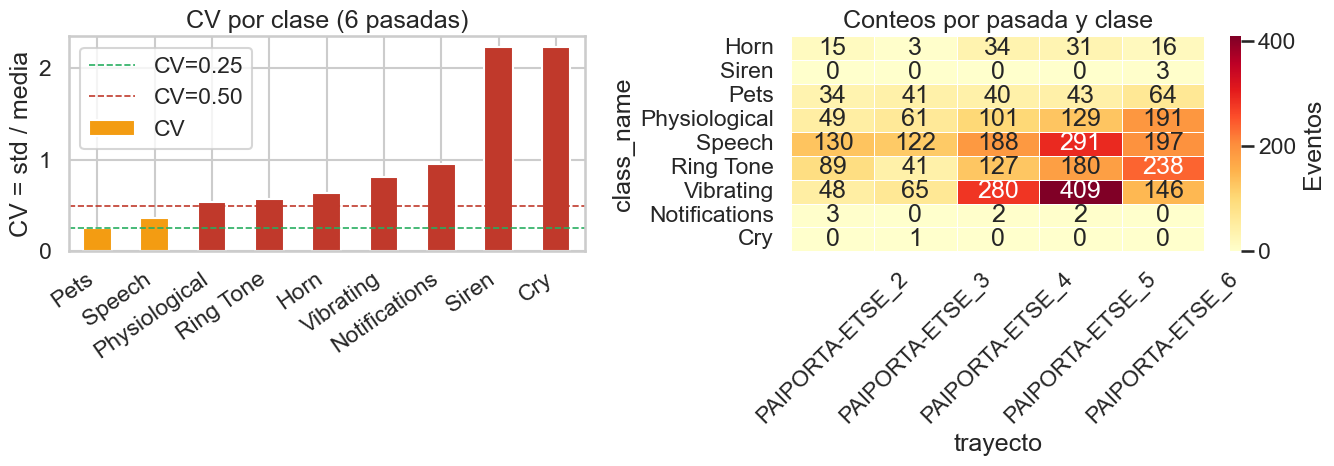


Jaccard entre pares de pasadas:


,PAIPORTA-ETSE_2,PAIPORTA-ETSE_3,PAIPORTA-ETSE_4,PAIPORTA-ETSE_5,PAIPORTA-ETSE_6
PAIPORTA-ETSE_2,1.000,0.594,0.600,0.518,0.573
PAIPORTA-ETSE_3,0.594,1.000,0.535,0.500,0.565
PAIPORTA-ETSE_4,0.600,0.535,1.000,0.602,0.601
PAIPORTA-ETSE_5,0.518,0.500,0.602,1.000,0.849
PAIPORTA-ETSE_6,0.573,0.565,0.601,0.849,1.000


Jaccard medio: 0.594

Celdas en >=4/5 pasadas: 98/178 = 55.1%


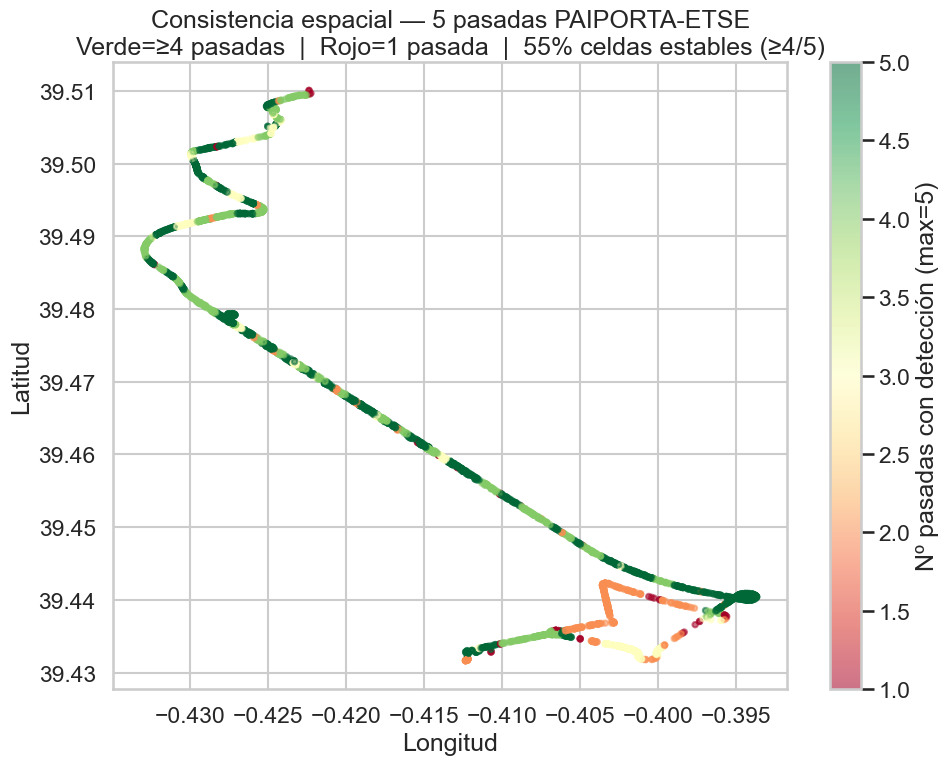

In [10]:
CLASS_ORDER_9 = [gu.CLASS_NAMES[i] for i in range(9)]

# Las 6 pasadas en dirección PAIPORTA-ETSE (mañana) y ETSE-PAIPORTA (tarde)
PASS_MIC = [f"PAIPORTA-ETSE_{i}" for i in range(1, 7)]
geo_6 = geo[geo["trayecto"].isin(PASS_MIC)].copy()
passes_found = sorted(geo_6["trayecto"].unique())
print("Pasadas encontradas:", passes_found)
print(f"Total eventos: {len(geo_6)}")

# ── CV por clase ──────────────────────────────────────────────────────────────
counts_pass = (
    geo_6.groupby(["trayecto", "class_name"])
    .size().unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER_9, fill_value=0)
)
cv_s = counts_pass.std() / counts_pass.mean().replace(0, np.nan)
cv_df = pd.DataFrame({
    "media":       counts_pass.mean().round(1),
    "std":         counts_pass.std().round(1),
    "CV":          cv_s.round(3),
    "fiabilidad":  cv_s.apply(lambda x: "alta" if x < 0.25 else ("media" if x < 0.50 else "baja")),
}).sort_values("CV")
print("\nCV por clase (6 pasadas PAIPORTA-ETSE):")
display(cv_df)

# Barras de CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cv = cv_df["CV"].apply(lambda x: "#27ae60" if x < 0.25 else ("#f39c12" if x < 0.50 else "#c0392b"))
cv_df["CV"].plot(kind="bar", ax=axes[0], color=colors_cv.values, edgecolor="white")
axes[0].axhline(0.25, color="#27ae60", ls="--", lw=1.2, label="CV=0.25")
axes[0].axhline(0.50, color="#c0392b", ls="--", lw=1.2, label="CV=0.50")
axes[0].set_title("CV por clase (6 pasadas)"); axes[0].set_xlabel("")
axes[0].set_ylabel("CV = std / media"); axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=35, ha="right")

# Conteos por pasada y clase (heatmap)
sns.heatmap(counts_pass.T, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1],
            linewidths=0.4, cbar_kws={"label": "Eventos"})
axes[1].set_title("Conteos por pasada y clase"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../outputs/nbA_cv_6passes.png", dpi=130, bbox_inches="tight"); plt.show()

# ── Consistencia espacial ─────────────────────────────────────────────────────
LAT_STEP, LON_STEP = 0.0009, 0.0013  # ~100 m
geo_6["cell"] = (
    (geo_6.lat / LAT_STEP).round().astype(int).astype(str) + "_" +
    (geo_6.lon / LON_STEP).round().astype(int).astype(str)
)
pass_cells = {tr: set(geo_6[geo_6.trayecto == tr]["cell"]) for tr in passes_found}

# Jaccard entre pares
from itertools import combinations
n_p = len(pass_cells)
jac_mat = np.eye(n_p)
names = list(pass_cells.keys())
for i, j in combinations(range(n_p), 2):
    a, b = pass_cells[names[i]], pass_cells[names[j]]
    jac = len(a & b) / len(a | b) if (a | b) else 0.0
    jac_mat[i, j] = jac_mat[j, i] = jac
jac_df = pd.DataFrame(jac_mat, index=names, columns=names).round(3)
print("\nJaccard entre pares de pasadas:")
display(jac_df)
print(f"Jaccard medio: {jac_mat[np.triu_indices(n_p, k=1)].mean():.3f}")

# % celdas en >=4/6 pasadas
all_cells = set().union(*pass_cells.values())
cell_cnt  = {c: sum(c in s for s in pass_cells.values()) for c in all_cells}
n_stable  = sum(v >= 4 for v in cell_cnt.values())
pct_stable = n_stable / len(all_cells) * 100
print(f"\nCeldas en >=4/{n_p} pasadas: {n_stable}/{len(all_cells)} = {pct_stable:.1f}%")

# Mapa de consistencia
geo_6["cell_cnt"] = geo_6["cell"].map(cell_cnt)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(geo_6.lon, geo_6.lat, c=geo_6["cell_cnt"],
                cmap="RdYlGn", vmin=1, vmax=n_p, alpha=0.55, s=15)
plt.colorbar(sc, ax=ax, label=f"Nº pasadas con detección (max={n_p})")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title(f"Consistencia espacial — {n_p} pasadas PAIPORTA-ETSE\n"
             f"Verde=≥{n_p-1} pasadas  |  Rojo=1 pasada  |  "
             f"{pct_stable:.0f}% celdas estables (≥4/{n_p})")
plt.tight_layout()
plt.savefig("../outputs/nbA_consistency_map.png", dpi=130, bbox_inches="tight"); plt.show()